In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.isothermal_flow import (
    NSIsothermalIntraTrajectoryGLSConfig,
    run_ns_isothermal_intra_trajectory_gls_experiment,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = NSIsothermalIntraTrajectoryGLSConfig(
    n_runs=25,          # lower this if the solver is too heavy
    N=64,
    Nt=1000,
    L=5.0,
    T=1.0,
    mu=1.0,
    K=1000,
    RT=1.0,
    sigma0=1e-3,
    alpha=0.025,
    stlsq_threshold=0.5,
    stlsq_alpha=1e-8,
    n_ensemble_models=100,
    seed_base=1,
    results_dir="results",
    results_filename="ns_isothermal_weighted_errors.csv",
)


# Navier-Stokes Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

We consider the two-dimensional isothermal compressible Navier--Stokes system on a periodic domain. Let $u(x,y,t)$ and $v(x,y,t)$ denote the two velocity components, and let \(\rho(x,y,t)\) denote the density. The governing equations are

$$
\begin{aligned}
u_t &= -\bigl(u u_x + v u_y\bigr) - \frac{1}{\rho}\Bigl(p_x - \mu (u_{xx}+u_{yy})\Bigr), \\
v_t &= -\bigl(u v_x + v v_y\bigr) - \frac{1}{\rho}\Bigl(p_y - \mu (v_{xx}+v_{yy})\Bigr), \\
\rho_t &= -\left(\frac{u\,p_x}{RT} + \frac{v\,p_y}{RT} + \rho u_x + \rho v_y\right),
\end{aligned}
$$

where the pressure is given by the isothermal equation of state

$$
p = \rho RT.
$$

In all simulations, we set
$$
\mu = 1, \qquad RT = 1.
$$

Let $U = (u,v,\rho)^\top$ denote the system state. To model perturbation error, we add a zero-mean random noise term $\epsilon$ to the state, defining

$$
U^{\mathrm{noisy}} = U + \epsilon.
$$

The perturbation is assumed to satisfy
$$
\mathbb{E}[\epsilon] = 0.
$$

The pointwise noise variance is modeled as

$$
\operatorname{Var}(\epsilon) = \left(\sigma_0 + \alpha \sqrt{u_t^2 + v_t^2}\right)^2,
$$

where $\sigma_0 > 0$ is a baseline noise level and $\alpha = 0.25$ controls the strength of the heteroscedastic component.

In [ ]:
print(f"Running isothermal NS GLS experiment with {cfg.n_runs} runs.")
df_errors_in_mem, L1_errors_in_mem, L0_errors_in_mem = run_ns_isothermal_intra_trajectory_gls_experiment(
     cfg
)


Running isothermal NS GLS experiment with 25 runs.
(x0)' = -0.991 x1x0_2 +  1.004 x2^-1x0_22 + -0.997 x0x0_1 + -1.001 x2^-1x2_1 +  1.000 x2^-1x0_11
(x1)' = -1.000 x1x1_2 + -1.001 x2^-1x2_2 +  1.002 x2^-1x1_22 + -0.998 x0x1_1 +  1.000 x2^-1x1_11
(x2)' = -1.000 x2x1_2 + -1.000 x1x2_2 + -1.000 x2x0_1 + -1.000 x0x2_1


MC isothermal NS GLS:  24%|██▍       | 6/25 [04:38<12:50, 40.53s/it]

In [ ]:
errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

methods = ["No weighting", "Variance GLS", "Ones GLS"]

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nMedian L1 errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L1_errors[m]):.3e}")

print("\nMedian L0 support errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L0_errors[m]):.3e}")



Median L1 errors (reloaded from CSV):
No weighting   : 4.201e-02
Variance GLS   : 1.955e-02
Ones GLS       : 5.450e-03

Median L0 support errors (reloaded from CSV):
No weighting   : 1.000e+00
Variance GLS   : 3.571e-01
Ones GLS       : 1.429e-01


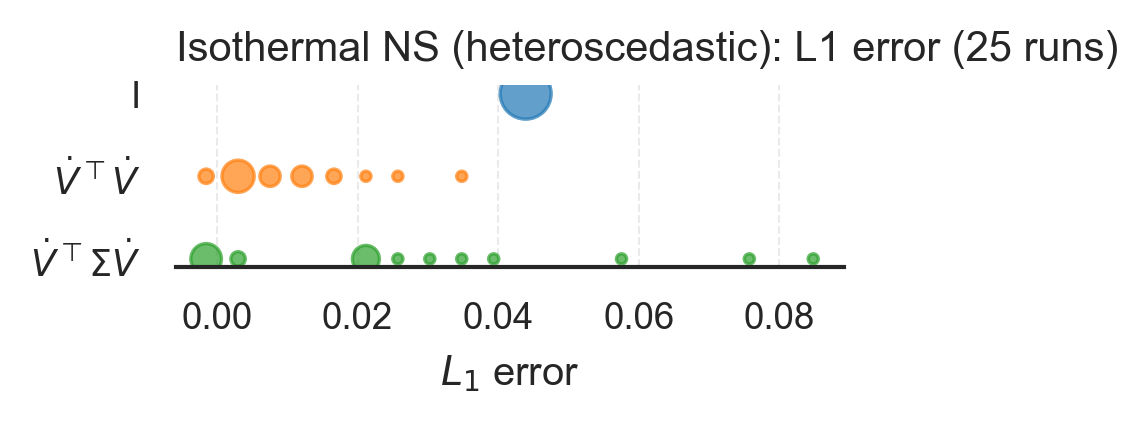

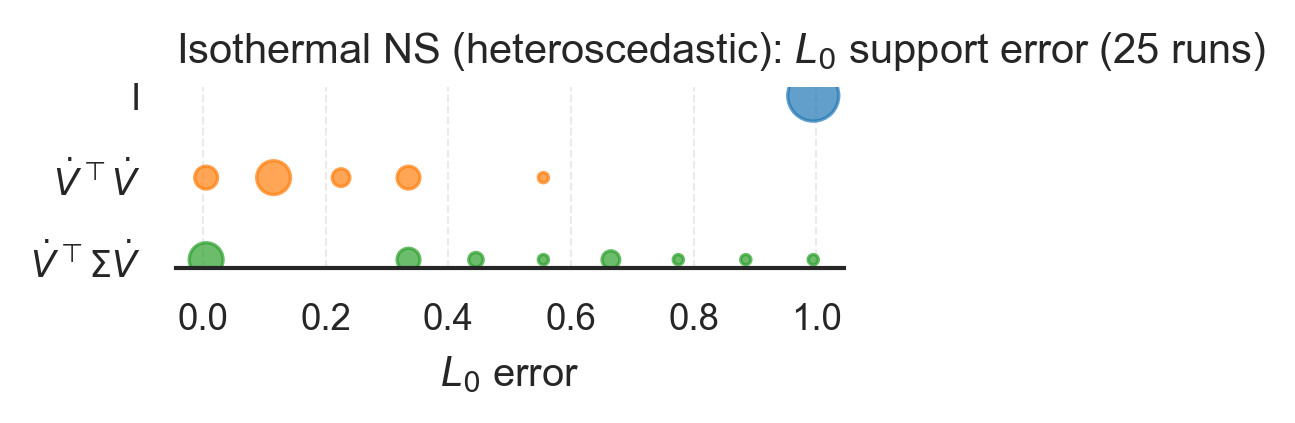

In [ ]:
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}^\top\Sigma\dot{V}$",r"$\dot{V}^\top\dot{V}$","I"]

bubble_hist(
    errors_dict=L1_errors,
    title=f"Isothermal NS (heteroscedastic): L1 error ({cfg.n_runs} runs)",
    xlabel=r"$L_1$ error",
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels
)

bubble_hist(
    errors_dict=L0_errors,
    title=f"Isothermal NS (heteroscedastic): $L_0$ support error ({cfg.n_runs} runs)",
    xlabel=r"$L_0$ error",
    n_bins=10,
    models_order=methods,
    colors=method_colors,
    labels=labels
)
